In [1]:
import numpy as np
import pandas as pd
import glob, os, subprocess, vcf, pysam, shutil, sparse, yaml, sys, pickle, itertools
from Bio import Entrez, Seq, SeqIO, SeqUtils
import scipy.stats as st

# utils files are in a separate folder
os.chdir("../")
sys.path.append("utils")
from saliency_utils import *
from inSilicoMut_utils import *
from data_utils import *

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
model_loci = pd.read_csv("data_processing/data_utils/drug_loci.csv")

BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
output_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_full = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_v4.csv")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")
h37Rv_coords_to_gene = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/h37Rv_coords_to_gene.csv")
h37Rv_coords_to_gene_dict = dict(zip(h37Rv_coords_to_gene['pos'], h37Rv_coords_to_gene['region']))

# full_data = pd.read_csv("data_processing/samples_pass_geno_QC.csv")
results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
cc_df_who = pd.read_csv("~/MtbQuantCNN/data_processing/data_utils/drug_CC.csv")

isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETO",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMK",
                  "Pretomanid": "PMD",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LFX",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}

df_MIC_ML = pd.read_csv("./MIC_data/MIC_ML.csv")
df_cryptic = pd.read_csv("./MIC_data/CRyPTIC_normalized.csv")

df_samples_geno = pd.read_csv("data_processing/samples_pass_geno_QC.csv")
# df_samples_geno['log_F2'] = np.log2(df_samples_geno['F2'])

genomic_data_dir = "/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"

drugs_lst = ['BDQ', 'EMB', 'ETO', 'INH', 'LFX', 'MXF', 'PZA', 'RIF']
cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETO': 5, 'MXF': 0.5, 'LFX': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_variants_WHO_catalog.csv").dropna(subset='variant').reset_index(drop=True)
all_drugs_insilico_pred = pd.read_csv("supplement/insilico_pred_all.csv")
H37Rv_insilico_pred = all_drugs_insilico_pred.query("variant=='MT_H37Rv'").reset_index(drop=True)

# How are Isolates whose MICs span the CC Predicted?

In [269]:
LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                   # "Other": "black"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }

In [233]:
df_pred_all = []

for drug in drugs_lst:

    if drug == 'PZA':
        model_path = f"{drug}_amino_acid"
    else:
        model_path = f"{drug}_lineage_amino_acid"

    cc = cc_dict[drug]
    
    # exclude samples with MIC reported as (some_val, inf], which is MIC > som_val. These are just laboratory dilution variations. We can probably infer they're resistant
    df_pred = pd.read_csv(f"{results_dir}/{model_path}/test_predictions.csv").query("Span_CC==1 & lower > 0 & upper <= 10000")#.query("lower >= @cc/2") #.query("lower >= @cc/4 & lower <= @cc/2") #
    df_pred['Drug'] = abbr_drug_dict[drug]    
    df_pred_all.append(df_pred)

df_pred_all = pd.concat(df_pred_all)
df_pred_all['y_pred_exp'] = np.exp2(df_pred_all['y_pred'])
df_pred_all = df_pred_all.merge(df_samples_geno.rename(columns={'ROLLINGDB_ID': 'Isolate'}))
df_pred_all['Lineage'] = df_pred_all['Lineage'].replace('BOV_AFRI', 'Other')

# some of these are weird. The MIC is reported as 1 in BMD. Idk what it means. They should all be susceptible, but BMD CC is 0.5 (tentatively)
df_pred_all = df_pred_all.query("~(Drug == 'Rifampicin' & DB_OF_ORIGIN == 'MICML' & upper >= @cc)")

# these are definitely just weird MIC reportings
df_pred_all = df_pred_all.query("~(lower * 2 != upper & ~(lower == 0.12 & upper==0.25))")
# df_pred_all = df_pred_all.query("DB_OF_ORIGIN != 'MICML'")

In [237]:
np.sort(df_pred_all.Drug.unique())

array(['Bedaquiline', 'Ethambutol', 'Ethionamide', 'Isoniazid'],
      dtype=object)

In [268]:
df_pred_all.Lineage.unique()

array(['2', '4', '3', '1'], dtype=object)

3/11
99/122
19/26
30/44


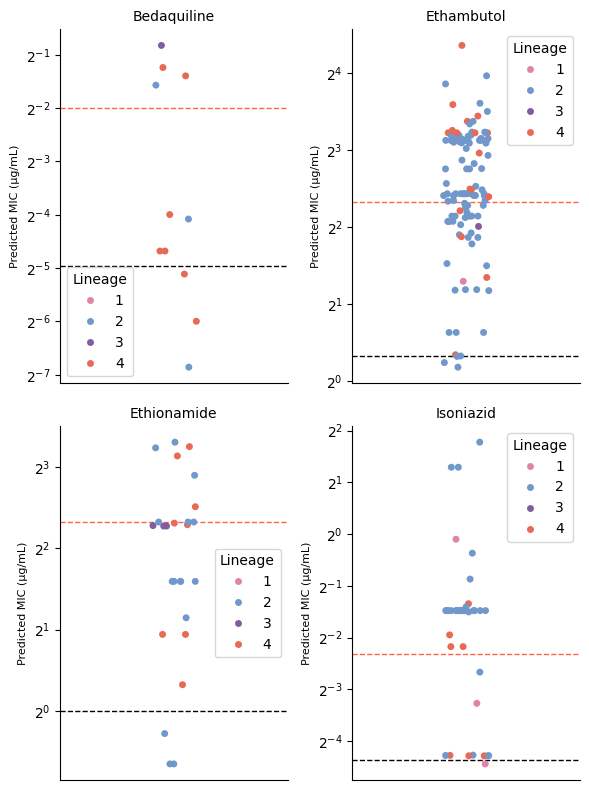

In [271]:
fig, ax = plt.subplots(2, 2, figsize=(6, 8))
ax = ax.flatten()
count_within_doubling = 0

for i, drug in enumerate(np.sort(df_pred_all.Drug.unique())):

    df_single_drug = df_pred_all.query("Drug==@drug")
    
    sns.stripplot(data=df_single_drug,
                  x='Drug',
                  y='y_pred_exp',
                  log_scale=2,
                  hue='Lineage',
                  palette=LinToColor_Dict,
                  hue_order=LinToColor_Dict.keys(),
                  ax=ax[i]
                 )

    cc = cc_dict[drug_abbr_dict[drug]]
    ref_pred = H37Rv_insilico_pred.query("drug==@drug").pred_MIC.values[0]
    
    sig_fig = 1
    ax[i].axhline(cc, label=f'CC = {cc}', color='tomato', linestyle='--', linewidth=1, zorder=0)
    ax[i].axhline(ref_pred, label=f'H37Rv = {np.round(ref_pred, sig_fig)}', color='black', linestyle='--', linewidth=1, zorder=0)
    
    ax[i].set_xticks([])
    
    num_predicted_within_doubling_of_CC = len(df_single_drug.query("y_pred_exp >= @cc/2 & y_pred_exp <= @cc * 2"))
    print(f"{num_predicted_within_doubling_of_CC}/{len(df_single_drug)}")
    count_within_doubling += num_predicted_within_doubling_of_CC
    
    # set the ylabels to be exponentiated values
    # ax[i].set_yticks(ticks=ax[i].get_yticks(), labels=[np.round(val, 2) for val in np.exp2(ax[i].get_yticks())], fontsize=8)
    
    # Set the font size for y-tick labels
    # plt.setp(y_ticks, fontsize=8)

    ax[i].set_xlabel('')
    ax[i].set_title(drug, fontsize=10)
    ax[i].set_ylabel('Predicted MIC (µg/mL)', fontsize=8)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig("results/isolates_span_CC.svg", bbox_inches='tight')

In [239]:
count_within_doubling / len(df_pred_all)

0.7438423645320197

In [240]:
df_pred_all.Drug.value_counts()

Drug
Ethambutol     122
Isoniazid       44
Ethionamide     26
Bedaquiline     11
Name: count, dtype: int64

In [191]:
122 / len(df_pred_all)

0.6009852216748769

In [241]:
df_pred_all.Isolate.nunique()

199

In [242]:
df_pred_all.query("Drug=='Isoniazid'")[['lower', 'upper']].value_counts()

lower  upper
0.12   0.25     39
       0.24      5
Name: count, dtype: int64

In [243]:
df_pred_all.query("Drug=='Ethionamide'")[['lower', 'upper']].value_counts()

lower  upper
3.125  6.25     17
4.000  8.00      9
Name: count, dtype: int64

In [244]:
df_pred_all.query("Drug=='Ethionamide'")

,Isolate,y_test,lower,upper,Span_CC,y_pred,Drug,y_pred_exp,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage
147,SAMN12787874,2.584963,4.000,8.00,1,2.510093,Ethionamide,5.696568,WHO_catalogue_2023,4.5,4.2.1.1.2,canetti,NaN,4.5,0.007812,4
149,SAMN12787881,2.584963,4.000,8.00,1,2.308812,Ethionamide,4.954748,WHO_catalogue_2023,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,0.004871,4
152,SAMN12787870,2.584963,4.000,8.00,1,1.146247,Ethionamide,2.213373,WHO_catalogue_2023,2.2.1,2.2.1.1.1.i3,"beijing,mungi","lin2.2.1,central_asia",NaN,0.010774,2
153,SAMN12787872,2.584963,4.000,8.00,1,2.278128,Ethionamide,4.850482,WHO_catalogue_2023,3,3.1.1,"east_african_indian,orygis,mungi",NaN,NaN,0.008338,3
154,SAMN12787875,2.584963,4.000,8.00,1,3.133499,Ethionamide,8.775606,WHO_catalogue_2023,4.5,4.2.1.1.2,NaN,NaN,4.5,0.004943,4
155,SAMN12787877,2.584963,4.000,8.00,1,2.272637,Ethionamide,4.832055,WHO_catalogue_2023,3,3.1.1,east_african_indian,NaN,NaN,0.009732,3
156,SAMN12787879,2.584963,4.000,8.00,1,2.289127,Ethionamide,4.887604,WHO_catalogue_2023,4.3.1,4.2.1.2.1.1.i2,"lam,westafrican2",NaN,4.3/LAM,0.004450,4
157,SAMN12787888,2.584963,4.000,8.00,1,3.247951,Ethionamide,9.500153,WHO_catalogue_2023,4.5,4.2.1.1.2,NaN,NaN,4.5,0.008009,4
158,SAMN12787891,2.584963,4.000,8.00,1,2.272637,Ethionamide,4.832055,WHO_catalogue_2023,3,3.1.1,"east_african_indian,ghana,mungi",NaN,NaN,0.008384,3
159,SAMN13813851,2.228819,3.125,6.25,1,2.322188,Ethionamide,5.000902,MICML,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN,0.021090,2


In [260]:
cc_df_who.query("Drug=='Ethionamide'")

,Medium,Value,Drug
14,UKMYC5,4.0,Ethionamide
15,UKMYC6,4.0,Ethionamide
42,7H11,10.0,Ethionamide
46,MGIT,5.0,Ethionamide
52,LJ,40.0,Ethionamide
65,7H10,5.0,Ethionamide
82,MYCOTB,4.0,Ethionamide


In [261]:
2.5*5/4, 5*5/4

(3.125, 6.25)

In [267]:
df_Shandu_MIC_ML = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/MIC_ML_consortium_MIC_table.csv")
df_Shandu_MIC_ML.query("ID=='C020'")[['ID', 'MEDIA', 'ETA']]

,ID,MEDIA,ETA
17,C020,MYCOTB,5


In [262]:
df_MIC_ML.query("ROLLINGDB_ID=='SAMN13813851'")

,ID,ROLLINGDB_ID,ISOLATION_LOCATION,DB_OF_ORIGIN,TESTING_LOCATION,MEDIA,RIF,INH,RFB,BDQ,...,EMB_PHENOTYPE_QUALITY,ETH_PHENOTYPE_QUALITY,INH_PHENOTYPE_QUALITY,KAN_PHENOTYPE_QUALITY,MXF_PHENOTYPE_QUALITY,OFX_PHENOTYPE_QUALITY,PAS_PHENOTYPE_QUALITY,RFB_PHENOTYPE_QUALITY,RIF_PHENOTYPE_QUALITY,STR_PHENOTYPE_QUALITY
1825,C020,SAMN13813851,NaN,CASS,Not specified,MYCOTB,8.0,4.0,0.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [178]:
df_rollingDB = pd.read_csv("~/MtbQuantCNN/MIC_data/rollingDB_MIC_raw.csv")

In [152]:
df_WHO_catalog = pd.read_csv("~/MtbQuantCNN/MIC_data/2023_WHO_catalog_MIC.csv")

In [259]:
df_WHO_catalog.query("name=='SAMN41468288'")

,name,drug_code,range,plate,Medium
126957,SAMN41468288,AMK,"(0.0,0.12]",MYCOTB,MYCOTB
126958,SAMN41468288,CYC,"(4.0,8]",MYCOTB,MYCOTB
126959,SAMN41468288,EMB,"(0.5,1]",MYCOTB,MYCOTB
126960,SAMN41468288,ETO,"(2.5,5]",MYCOTB,MYCOTB
126961,SAMN41468288,INH,"(0.25,0.5]",MYCOTB,MYCOTB
126962,SAMN41468288,KAN,"(2.5,5]",MYCOTB,MYCOTB
126963,SAMN41468288,MB,"(1.0,2]",MYCOTB,MYCOTB
126964,SAMN41468288,MXF,"(0.25,0.5]",MYCOTB,MYCOTB
126965,SAMN41468288,OFX,"(2.0,4]",MYCOTB,MYCOTB
126966,SAMN41468288,PAS,"(0,0.5)",MYCOTB,MYCOTB


In [246]:
cc_df_who.query("Drug=='Ethambutol'")

,Medium,Value,Drug
4,UKMYC5,4.0,Ethambutol
5,UKMYC6,4.0,Ethambutol
39,7H10,5.0,Ethambutol
60,7H11,7.5,Ethambutol
64,LJ,2.0,Ethambutol
74,MGIT,5.0,Ethambutol
78,MYCOTB,4.0,Ethambutol


In [224]:
isolate_variants.query("ROLLINGDB_ID=='SAMN13814015' & drug == 'Isoniazid'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
77765,SAMN13814015,575907,C,T,PASS,1305.0,False,0.99,42.0,32.0,59.0,0.0,0.0,missense_variant,mshA,c.560C>T,p.Ala187Val,mshA_p.Ala187Val,Isoniazid,5) Not assoc w R
77781,SAMN13814015,1406760,T,TG,PASS,1038.0,False,0.94,33.0,31.0,58.0,31.0,0.0,frameshift_variant,Rv1258c,c.580_581insC,p.Glu194fs,Rv1258c_p.Glu194fs,Isoniazid,5) Not assoc w R
77784,SAMN13814015,1406760,T,TG,PASS,1038.0,NaN,0.94,33.0,31.0,58.0,NaN,NaN,frameshift_variant,Rv1258c,NaN,NaN,Rv1258c_LoF,Isoniazid,3) Uncertain significance
77789,SAMN13814015,1673425,C,T,PASS,1897.0,False,1.00,57.0,33.0,59.0,0.0,0.0,intergenic_region,Rv1482c-fabG1,n.1673425C>T,NaN,inhA_c.-777C>T,Isoniazid,1) Assoc w R
77801,SAMN13814015,2154724,C,A,PASS,1493.0,False,1.00,45.0,33.0,59.0,0.0,0.0,missense_variant,katG,c.1388G>T,p.Arg463Leu,katG_p.Arg463Leu,Isoniazid,5) Not assoc w R


In [125]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA5282459' & drug == 'Moxifloxacin'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
103163,SAMEA5282459,6518,G,A,PASS,3101.0,False,1.0,85.0,36.0,60.0,0.0,0.0,missense_variant,gyrB,c.1279G>A,p.Val427Met,gyrB_p.Val427Met,Moxifloxacin,3) Uncertain significance
103165,SAMEA5282459,7362,G,C,PASS,3060.0,False,1.0,84.0,36.0,59.0,0.0,0.0,missense_variant,gyrA,c.61G>C,p.Glu21Gln,gyrA_p.Glu21Gln,Moxifloxacin,5) Not assoc w R


In [85]:
df_pred_all.query("Drug=='Bedaquiline'")[['lower', 'upper']].drop_duplicates()

,lower,upper
0,0.156,0.312
8,0.160,0.320


In [99]:
drug = 'Bedaquiline'
ref_pred = H37Rv_insilico_pred.query("drug==@drug").pred_MIC.values[0]

search_isolates = df_pred_all.query("Drug==@drug & y_pred_exp < @ref_pred").sort_values('y_pred_exp').Isolate.values

df_pred_all.query("Drug==@drug & y_pred_exp < @ref_pred").sort_values('y_pred_exp')

,Isolate,y_test,lower,upper,Span_CC,y_pred,Drug,y_pred_exp,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage
0,SAMN37124201,-2.095420,0.156,0.312,1,-6.857486,Bedaquiline,0.008624,MICML,2.2.1,2.2.1.1.1,"beijing,mungi",lin2.2.1,NaN,0.009393,2
2,SAMN37124224,-2.095420,0.156,0.312,1,-5.996750,Bedaquiline,0.015660,MICML,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,0.005389,4
9,TN15617,-2.058894,0.160,0.320,1,-5.111932,Bedaquiline,0.028917,MICML,4.1.1,4.1.i1.2.1,xtype,NaN,4,0.027660,4


In [100]:
isolate_variants.query("ROLLINGDB_ID in @search_isolates & drug==@drug")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
6137,SAMN37124201,775639,T,C,PASS,5163.0,False,1.00,155.0,34.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2842A>G,p.Ile948Val,mmpL5_p.Ile948Val,Bedaquiline,4) Not assoc w R - Interim
6139,SAMN37124201,776100,G,A,PASS,5212.0,False,1.00,148.0,35.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2381C>T,p.Thr794Ile,mmpL5_p.Thr794Ile,Bedaquiline,4) Not assoc w R - Interim
6141,SAMN37124201,776182,C,T,PASS,4596.0,False,1.00,132.0,35.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R
6143,SAMN37124201,778979,C,A,PASS,4317.0,False,1.00,126.0,34.0,59.0,0.0,0.0,intergenic_region,mmpS5-Rv0678,n.778979C>A,NaN,mmpS5_c.-74G>T,Bedaquiline,4) Not assoc w R - Interim
6146,SAMN37124201,779414,T,G,Amb,4014.0,False,0.55,141.0,35.0,60.0,0.0,0.0,missense_variant,Rv0678,c.425T>G,p.Leu142Arg,Rv0678_p.Leu142Arg,Bedaquiline,3) Uncertain significance
6169,SAMN37124201,2223293,T,C,PASS,5729.0,False,1.00,162.0,35.0,60.0,0.0,0.0,intergenic_region,Rv1979c-mpt64,n.2223293T>C,NaN,Rv1979c_c.-129A>G,Bedaquiline,4) Not assoc w R - Interim
6176,SAMN37124201,3625065,T,G,PASS,4066.0,False,1.00,118.0,34.0,60.0,0.0,0.0,missense_variant,mtrB,c.1549A>C,p.Met517Leu,mtrB_p.Met517Leu,Bedaquiline,3) Uncertain significance
6178,SAMN37124201,3626562,G,A,PASS,4481.0,False,1.00,133.0,34.0,60.0,0.0,0.0,missense_variant,mtrB,c.52C>T,p.Pro18Ser,mtrB_p.Pro18Ser,Bedaquiline,3) Uncertain significance
7361,SAMN37124224,775639,T,C,PASS,5783.0,False,1.00,167.0,35.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2842A>G,p.Ile948Val,mmpL5_p.Ile948Val,Bedaquiline,4) Not assoc w R - Interim
7372,SAMN37124224,2223051,C,G,PASS,6622.0,False,1.00,194.0,34.0,60.0,0.0,0.0,missense_variant,Rv1979c,c.114G>C,p.Glu38Asp,Rv1979c_p.Glu38Asp,Bedaquiline,3) Uncertain significance


In [48]:
df_MIC_ML = pd.read_csv("~/MtbQuantCNN/MIC_data/MIC_ML.csv")

In [69]:
df_MIC_ML.query("ROLLINGDB_ID in ['UH00236601']")[['ROLLINGDB_ID', 'DB_OF_ORIGIN', 'ISOLATION_LOCATION', 'RIF', 'MEDIA']]

,ROLLINGDB_ID,DB_OF_ORIGIN,ISOLATION_LOCATION,RIF,MEDIA
1510,UH00236601,NICD,South Africa,1.0,BMD


In [57]:
cc_df_who.query("Drug=='Rifampicin'")

cc_df_who.query("Medium=='BMD'")

In [68]:
isolate_variants.query("ROLLINGDB_ID=='UH00236601' & drug=='Rifampicin'")#" & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
57507,UH00236601,759746,C,T,PASS,4470.0,False,0.99,148.0,31.0,58.0,0.0,0.0,intergenic_region,Rv0666-rpoB,n.759746C>T,NaN,rpoB_c.-61C>T,Rifampicin,5) Not assoc w R
57508,UH00236601,762434,T,G,PASS,4560.0,False,0.99,143.0,34.0,58.0,0.0,0.0,synonymous_variant,rpoB,c.2628T>G,p.Gly876Gly,rpoB_c.2628T>G,Rifampicin,5) Not assoc w R
57509,UH00236601,763031,T,C,PASS,5151.0,False,1.00,153.0,34.0,60.0,0.0,0.0,synonymous_variant,rpoB,c.3225T>C,p.Ala1075Ala,rpoB_c.3225T>C,Rifampicin,5) Not assoc w R
57537,UH00236601,2782498,G,A,PASS,7715.0,False,0.99,235.0,34.0,59.0,0.0,0.0,synonymous_variant,Rv2477c,c.1545C>T,p.Asp515Asp,Rv2477c_c.1545C>T,Rifampicin,5) Not assoc w R
57543,UH00236601,3065025,C,T,PASS,6832.0,False,1.00,204.0,34.0,59.0,0.0,0.0,synonymous_variant,Rv2752c,c.1167G>A,p.Arg389Arg,Rv2752c_c.1167G>A,Rifampicin,4) Not assoc w R - Interim
57545,UH00236601,3625065,T,G,PASS,4587.0,False,1.00,137.0,34.0,59.0,0.0,0.0,missense_variant,mtrB,c.1549A>C,p.Met517Leu,mtrB_p.Met517Leu,Rifampicin,5) Not assoc w R
57546,UH00236601,3878579,G,T,LowCov,76.0,False,1.00,2.0,38.0,60.0,0.0,0.0,intergenic_region,rpoA-rpsD,n.3878579G>T,NaN,rpoA_c.-72C>A,Rifampicin,3) Uncertain significance
57551,UH00236601,4138622,G,A,PASS,7265.0,False,1.00,214.0,34.0,59.0,0.0,0.0,synonymous_variant,glpK,c.1134C>T,p.Arg378Arg,glpK_c.1134C>T,Rifampicin,5) Not assoc w R


In [47]:
isolate_variants.query("ROLLINGDB_ID=='JA00225792' & drug=='Rifampicin'")#" & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']")


,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
43999,JA00225792,1254156,A,C,PASS,3092.0,False,0.99,100.0,32.0,58.0,0.0,0.0,missense_variant,Rv1129c,c.379T>G,p.Leu127Val,Rv1129c_p.Leu127Val,Rifampicin,3) Uncertain significance


In [31]:
df_pred_all.query("Lineage=='Other'")

,Isolate,y_test,lower,upper,Span_CC,y_pred,Drug,y_pred_exp,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage
377,SAMEA3402913,-1.736966,0.10,0.50,1,1.389277,Isoniazid,2.619474,WHO_catalogue_2023,BOV_AFRI,NaN,"bovis,canetti",NaN,NaN,0.014176,Other
493,SAMN27762526,-2.251539,0.18,0.24,1,-3.641866,Isoniazid,0.080110,WHO_catalogue_2023,BOV_AFRI,NaN,"bcg,ghana,ethiopian,mungi",NaN,NaN,0.020460,Other


In [26]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA3402913' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
772059,SAMEA3402913,7572,T,C,PASS,2724.0,False,1.00,78.0,35.0,60.0,0.0,0.0,missense_variant,gyrA,c.271T>C,p.Ser91Pro,gyrA_p.Ser91Pro,Levofloxacin,1) Assoc w R
772060,SAMEA3402913,7572,T,C,PASS,2724.0,False,1.00,78.0,35.0,60.0,0.0,0.0,missense_variant,gyrA,c.271T>C,p.Ser91Pro,gyrA_p.Ser91Pro,Moxifloxacin,1) Assoc w R
772077,SAMEA3402913,761155,C,T,PASS,2872.0,False,1.00,85.0,34.0,60.0,0.0,0.0,missense_variant,rpoB,c.1349C>T,p.Ser450Leu,rpoB_p.Ser450Leu,Rifampicin,1) Assoc w R
772086,SAMEA3402913,781687,A,G,PASS,2750.0,False,0.99,79.0,36.0,60.0,0.0,0.0,missense_variant,rpsL,c.128A>G,p.Lys43Arg,rpsL_p.Lys43Arg,Streptomycin,1) Assoc w R
772092,SAMEA3402913,1473246,A,G,PASS,2486.0,False,1.00,69.0,36.0,60.0,0.0,0.0,non_coding_transcript_exon_variant,rrs,n.1401A>G,NaN,rrs_n.1401A>G,Amikacin,1) Assoc w R
772093,SAMEA3402913,1473246,A,G,PASS,2486.0,False,1.00,69.0,36.0,60.0,0.0,0.0,non_coding_transcript_exon_variant,rrs,n.1401A>G,NaN,rrs_n.1401A>G,Capreomycin,1) Assoc w R
772094,SAMEA3402913,1473246,A,G,PASS,2486.0,False,1.00,69.0,36.0,60.0,0.0,0.0,non_coding_transcript_exon_variant,rrs,n.1401A>G,NaN,rrs_n.1401A>G,Kanamycin,1) Assoc w R
772097,SAMEA3402913,1673425,C,T,PASS,2240.0,False,1.00,74.0,30.0,60.0,0.0,0.0,intergenic_region,Rv1482c-fabG1,n.1673425C>T,NaN,inhA_c.-777C>T,Ethionamide,1) Assoc w R
772098,SAMEA3402913,1673425,C,T,PASS,2240.0,False,1.00,74.0,30.0,60.0,0.0,0.0,intergenic_region,Rv1482c-fabG1,n.1673425C>T,NaN,inhA_c.-777C>T,Isoniazid,1) Assoc w R
772119,SAMEA3402913,2289073,G,C,PASS,1794.0,False,1.00,52.0,35.0,60.0,0.0,0.0,missense_variant,pncA,c.169C>G,p.His57Asp,pncA_p.His57Asp,Pyrazinamide,1) Assoc w R


In [122]:
all_drugs_insilico_pred.query("variant=='mmpS5_c.-74G>T'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
567,mmpS5_c.-74G>T,-5.068697,0.029797,upstream_gene_variant,0.25,mmpLS5,4) Not assoc w R - Interim,0.029826,0.999018,-0.001417,mmpS5,Bedaquiline


In [93]:
df_MIC_ML.loc[df_MIC_ML['ROLLINGDB_ID'].isin(df_pred_all.query("Drug=='Moxifloxacin'").Isolate)]

,ID,ROLLINGDB_ID,ISOLATION_LOCATION,DB_OF_ORIGIN,TESTING_LOCATION,MEDIA,RIF,INH,RFB,BDQ,...,EMB_PHENOTYPE_QUALITY,ETH_PHENOTYPE_QUALITY,INH_PHENOTYPE_QUALITY,KAN_PHENOTYPE_QUALITY,MXF_PHENOTYPE_QUALITY,OFX_PHENOTYPE_QUALITY,PAS_PHENOTYPE_QUALITY,RFB_PHENOTYPE_QUALITY,RIF_PHENOTYPE_QUALITY,STR_PHENOTYPE_QUALITY
1558,19-002-0048,19-002-0048,Australia,NSW,Not specified,NSW_sensititre_plate,16.0,8.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
df_MIC_ML.loc[df_MIC_ML['ROLLINGDB_ID'].isin(df_pred_all.query("Drug=='Rifampicin'").Isolate)]

,ID,ROLLINGDB_ID,ISOLATION_LOCATION,DB_OF_ORIGIN,TESTING_LOCATION,MEDIA,RIF,INH,RFB,BDQ,...,EMB_PHENOTYPE_QUALITY,ETH_PHENOTYPE_QUALITY,INH_PHENOTYPE_QUALITY,KAN_PHENOTYPE_QUALITY,MXF_PHENOTYPE_QUALITY,OFX_PHENOTYPE_QUALITY,PAS_PHENOTYPE_QUALITY,RFB_PHENOTYPE_QUALITY,RIF_PHENOTYPE_QUALITY,STR_PHENOTYPE_QUALITY
1146,BF01114045,BF01114045,South Africa,NICD,Not specified,BMD,1.0,0.048,NaN,0.008,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1172,JA00225792,JA00225792,South Africa,NICD,Not specified,BMD,1.0,0.048,NaN,0.125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1178,JF00065486,JF00065486,South Africa,NICD,Not specified,BMD,1.0,0.096,NaN,0.062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1186,JG00421329,JG00421329,South Africa,NICD,Not specified,BMD,1.0,0.012,NaN,0.031,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1194,NC00179466,NC00179466,South Africa,NICD,Not specified,BMD,1.0,0.048,NaN,0.062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1255,RJ00263599,RJ00263599,South Africa,NICD,Not specified,BMD,1.0,0.048,NaN,0.125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1323,TRL0095895,TRL0095895,South Africa,NICD,Not specified,BMD,1.0,0.048,NaN,0.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1458,TRL0115412,TRL0115412,South Africa,NICD,Not specified,BMD,1.0,0.096,NaN,0.062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1495,TRL0116115,TRL0116115,South Africa,NICD,Not specified,BMD,1.0,0.096,NaN,0.125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1505,TRL0116714,TRL0116714,South Africa,NICD,Not specified,BMD,1.0,0.048,NaN,0.125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [85]:
isolate_variants.query("ROLLINGDB_ID=='TRL0116714' & drug=='Rifampicin'")


,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
57266,TRL0116714,761095,T,C,PASS,3065.0,False,1.00,93.0,33.0,59.0,0.0,0.0,missense_variant,rpoB,c.1289T>C,p.Leu430Pro,rpoB_p.Leu430Pro,Rifampicin,1) Assoc w R
57267,TRL0116714,763031,T,C,PASS,2649.0,False,1.00,78.0,34.0,59.0,0.0,0.0,synonymous_variant,rpoB,c.3225T>C,p.Ala1075Ala,rpoB_c.3225T>C,Rifampicin,5) Not assoc w R
57268,TRL0116714,763552,C,T,PASS,3828.0,False,0.99,124.0,32.0,59.0,0.0,0.0,synonymous_variant,rpoC,c.183C>T,p.Tyr61Tyr,rpoC_c.183C>T,Rifampicin,5) Not assoc w R
57269,TRL0116714,763884,C,T,PASS,3001.0,False,1.00,97.0,32.0,59.0,0.0,0.0,missense_variant,rpoC,c.515C>T,p.Ala172Val,rpoC_p.Ala172Val,Rifampicin,5) Not assoc w R
57270,TRL0116714,763886,C,A,PASS,3195.0,False,1.00,98.0,33.0,59.0,0.0,0.0,synonymous_variant,rpoC,c.517C>A,p.Arg173Arg,rpoC_c.517C>A,Rifampicin,5) Not assoc w R
57303,TRL0116714,3624486,T,C,PASS,2564.0,False,1.00,78.0,33.0,59.0,0.0,0.0,missense_variant,lpqB,c.425A>G,p.Asp142Gly,lpqB_p.Asp142Gly,Rifampicin,5) Not assoc w R
57305,TRL0116714,3625065,T,G,PASS,1877.0,False,1.00,55.0,34.0,59.0,0.0,0.0,missense_variant,mtrB,c.1549A>C,p.Met517Leu,mtrB_p.Met517Leu,Rifampicin,5) Not assoc w R
57307,TRL0116714,3626467,C,T,PASS,3526.0,False,1.00,115.0,31.0,58.0,0.0,0.0,synonymous_variant,mtrB,c.147G>A,p.Leu49Leu,mtrB_c.147G>A,Rifampicin,5) Not assoc w R
57314,TRL0116714,4138377,A,G,PASS,2907.0,False,1.00,88.0,33.0,58.0,0.0,0.0,missense_variant,glpK,c.1379T>C,p.Val460Ala,glpK_p.Val460Ala,Rifampicin,5) Not assoc w R


In [54]:
cc = 0.5
df_pred.query("lower >= @cc/2")

,Isolate,y_test,lower,upper,Span_CC,y_pred,Drug
2358,BF01114045,-0.434403,0.48,1.0,1,-4.016479,Rifampicin
2359,JA00225792,-0.434403,0.48,1.0,1,-4.084622,Rifampicin
2360,JF00065486,-0.434403,0.48,1.0,1,-3.975904,Rifampicin
2361,JG00421329,-0.434403,0.48,1.0,1,-4.077569,Rifampicin
2362,NC00179466,-0.434403,0.48,1.0,1,-4.016479,Rifampicin
2363,RJ00263599,-0.434403,0.48,1.0,1,-4.070399,Rifampicin
2364,TRL0095895,-0.434403,0.48,1.0,1,-4.016479,Rifampicin
2365,TRL0115412,-0.434403,0.48,1.0,1,-3.975904,Rifampicin
2366,TRL0116115,-0.434403,0.48,1.0,1,-4.027418,Rifampicin
2367,TRL0116714,-0.434403,0.48,1.0,1,-0.463803,Rifampicin


In [24]:
df_RIF = pd.read_csv(f"{data_dir}/RIF/data_for_model.csv")

In [25]:
df_RIF.query("ROLLINGDB_ID=='SAMEA5282322'")

,ROLLINGDB_ID,RIF_MEDIA,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
11527,SAMEA5282322,7H10,0.0375,0.0375,inf,LJ,farhat_internal,1.1.2,1.1.2,"indo_oceanic,ethiopian,mungi",NaN,NaN,0.016431,1,-5.927435,1,NaN,NaN,test_set
